<a href="https://colab.research.google.com/github/Hmm-Asadullah/MLR-and-Logistic-Regression/blob/main/BSEF23M012_Asadullah_A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('Housing.csv')

print(df.head())
print(df.describe())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545

In [6]:
threshold = 0.3 * df.shape[1]
df = df.dropna(thresh=int(df.shape[1] - threshold))
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    col_mean = df[col].mean()
    df[col] = df[col].fillna(col_mean)

In [7]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

furnish_map = {'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}
df['furnishingstatus'] = df['furnishingstatus'].map(furnish_map)

print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 2  
1                 2  
2                 1  
3                 2  
4                 2  


In [8]:
feature_cols = [col for col in df.columns if col != 'price']
X_raw = df[feature_cols].values.astype(float)
y_raw = df['price'].values.astype(float)

feature_means = X_raw.mean(axis=0)
feature_stds  = X_raw.std(axis=0)

feature_stds[feature_stds == 0] = 1

X_scaled = (X_raw - feature_means) / feature_stds
y_mean = y_raw.mean()
y_std  = y_raw.std()
y_scaled = (y_raw - y_mean) / y_std

print(f"Feature means: {feature_means[:3].round(2)}")
print(f"Feature stds  : {feature_stds[:3].round(2)}")

Feature means: [5.15054e+03 2.97000e+00 1.29000e+00]
Feature stds  : [2.16815e+03 7.40000e-01 5.00000e-01]


In [9]:
def train_test_split(X, y, test_size=0.2):
    m = X.shape[0]
    indices = np.random.permutation(m)
    test_count = int(m * test_size)
    test_idx  = indices[:test_count]
    train_idx = indices[test_count:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2)

print(f"Total : {X_scaled.shape[0]}")
print(f"Training set  : {X_train.shape[0]}")
print(f"Test set      : {X_test.shape[0]}")

Total : 545
Training set  : 436
Test set      : 109


In [10]:
def add_bias_column(X):
    m = X.shape[0]
    bias_col = np.ones((m, 1))
    return np.hstack([bias_col, X])


X_train_b = add_bias_column(X_train)
X_test_b  = add_bias_column(X_test)

print(f"X_train_b shape: {X_train_b.shape}")
print(f"X_test_b  shape: {X_test_b.shape}")


X_train_b shape: (436, 13)
X_test_b  shape: (109, 13)


In [11]:
def hypothesis_mlr(X_b, theta):
    return X_b @ theta

theta_init = np.zeros(X_train_b.shape[1])
h_check = hypothesis_mlr(X_train_b, theta_init)
print(f"Hypothesis function check (all-zero theta):first 3 values = {h_check[:3]}")

Hypothesis function check (all-zero theta):first 3 values = [0. 0. 0.]


In [12]:
def cost_mse(X_b, y, theta):
    m = len(y)
    h = hypothesis_mlr(X_b, theta)
    errors = h - y
    J = (1 / (2 * m)) * np.dot(errors, errors)
    return J


initial_cost = cost_mse(X_train_b, y_train, theta_init)
print(f"Initial MSE cost (all-zero theta): {initial_cost:.6f}")

Initial MSE cost (all-zero theta): 0.537096


In [13]:
def gradient_descent_mlr(X_b, y, theta, alpha=0.01, iterations=1000):
    m = len(y)
    theta = theta.copy()
    cost_history = []

    for i in range(iterations):
        h = hypothesis_mlr(X_b, theta)
        gradient = X_b.T @ (h - y)
        theta -= (alpha / m) * gradient
        cost_history.append(cost_mse(X_b, y, theta))

    return theta, cost_history

alpha_mlr = 0.01
iterations_mlr = 1000
theta_init_mlr = np.zeros(X_train_b.shape[1])

theta_mlr, cost_history_mlr = gradient_descent_mlr(
    X_train_b, y_train, theta_init_mlr, alpha=alpha_mlr, iterations=iterations_mlr
)

print(f"Final theta values:\n{theta_mlr.round(4)}")
print(f"\nMinimized Training Cost (MSE): {cost_history_mlr[-1]:.6f}")

test_mse = cost_mse(X_test_b, y_test, theta_mlr) * 2
train_mse_pure = cost_history_mlr[-1] * 2

Final theta values:
[0.0036 0.3087 0.0416 0.2901 0.2152 0.076  0.0714 0.0769 0.0637 0.2172
 0.135  0.152  0.0909]

Minimized Training Cost (MSE): 0.162247


---
#Logistic Regression — Classification

In [14]:
median_price = np.median(y_raw)
y_binary = (y_raw > median_price).astype(float)

print(f"Median price: {median_price:,.0f}")
print(f"Class 1: {y_binary.sum():.0f} samples")
print(f"Class 0: {(y_binary == 0).sum():.0f} samples")

X_scaled_clf = (X_raw - feature_means) / feature_stds

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_scaled_clf, y_binary, test_size=0.2
)

X_train_clf_b = add_bias_column(X_train_clf)
X_test_clf_b  = add_bias_column(X_test_clf)

print(f"\nClassification Train set: {X_train_clf_b.shape[0]} samples")
print(f"Classification Test set : {X_test_clf_b.shape[0]} samples")

Median price: 4,340,000
Class 1 (expensive): 270 samples
Class 0 (affordable): 275 samples

Classification Train set: 436 samples
Classification Test set : 109 samples


In [18]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

print(f"sigmoid(0)    = {sigmoid(0):.6f}")
print(f"sigmoid(-100) = {sigmoid(-100):.10f}")
print(f"sigmoid(100)  = {sigmoid(100):.10f}")

sigmoid(0)    = 0.500000
sigmoid(-100) = 0.0000000000
sigmoid(100)  = 1.0000000000


In [20]:
def cost_binary_crossentropy(X_b, y, theta, epsilon=1e-8):
    m = len(y)
    h = sigmoid(X_b @ theta)
    h = np.clip(h, epsilon, 1 - epsilon)
    J = -(1 / m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return J

theta_init_clf = np.zeros(X_train_clf_b.shape[1])
initial_ce_cost = cost_binary_crossentropy(X_train_clf_b, y_train_clf, theta_init_clf)
print(f"Initial cross-entropy cost (all-zero theta): {initial_ce_cost:.6f}")
print(f"(Expected ≈ ln(2) = {np.log(2):.6f} for balanced classes with zero weights)")

Initial cross-entropy cost (all-zero theta): 0.693147
(Expected ≈ ln(2) = 0.693147 for balanced classes with zero weights)


In [23]:
def gradient_descent_logistic(X_b, y, theta, alpha=0.01, iterations=1000):
    m = len(y)
    theta = theta.copy()
    cost_history = []

    for i in range(iterations):
        h = sigmoid(X_b @ theta)
        gradient = X_b.T @ (h - y)
        theta -= (alpha / m) * gradient
        cost_history.append(cost_binary_crossentropy(X_b, y, theta))

    return theta, cost_history

theta_init_clf = np.zeros(X_train_clf_b.shape[1])
theta_lr001, cost_lr001 = gradient_descent_logistic(
    X_train_clf_b, y_train_clf, theta_init_clf, alpha=0.01, iterations=1000
)

theta_lr01, cost_lr01 = gradient_descent_logistic(
    X_train_clf_b, y_train_clf, theta_init_clf, alpha=0.1, iterations=1000
)

print(f"α=0.01 — Final cost after 1000 iterations: {cost_lr001[-1]:.6f}")
print(f"α=0.1 — Final cost after 1000 iterations: {cost_lr01[-1]:.6f}")
print("Analysis: α=0.1 converges faster (lower final cost) because the larger step size")
print("covers more ground per iteration.")

α=0.01 — Final cost after 1000 iterations: 0.359697
α=0.1 — Final cost after 1000 iterations: 0.347348
Analysis: α=0.1 converges faster (lower final cost) because the larger step size
covers more ground per iteration.


In [28]:
def predict_logistic(X_b, theta, threshold=0.5):
    probs = sigmoid(X_b @ theta)
    return (probs >= threshold).astype(int)

def confusion_matrix(y_true, y_pred):
    TP = int(np.sum((y_pred == 1) & (y_true == 1)))
    TN = int(np.sum((y_pred == 0) & (y_true == 0)))
    FP = int(np.sum((y_pred == 1) & (y_true == 0)))
    FN = int(np.sum((y_pred == 0) & (y_true == 1)))
    cm = np.array([[TN, FP],
                   [FN, TP]])
    return cm, TP, TN, FP, FN

y_pred_clf = predict_logistic(X_test_clf_b, theta_lr01)

accuracy = np.sum(y_pred_clf == y_test_clf) / len(y_test_clf)

cm, TP, TN, FP, FN = confusion_matrix(y_test_clf, y_pred_clf)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"\nCounts — TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
print(f"Accuracy check: (TP+TN)/total = ({TP}+{TN})/{len(y_test_clf)} = {(TP+TN)/len(y_test_clf)*100:.2f}%")
print("\nConfusion Matrix")
print("                 Predicted 0    Predicted 1")
print(f"  Actual 0     {TN:>8}      {FP:>8}")
print(f"  Actual 1     {FN:>8}      {TP:>8}")

Test Accuracy: 77.06%

Counts — TP: 38, TN: 46, FP: 12, FN: 13
Accuracy check: (TP+TN)/total = (38+46)/109 = 77.06%

Confusion Matrix
                 Predicted 0    Predicted 1
  Actual 0           46            12
  Actual 1           13            38


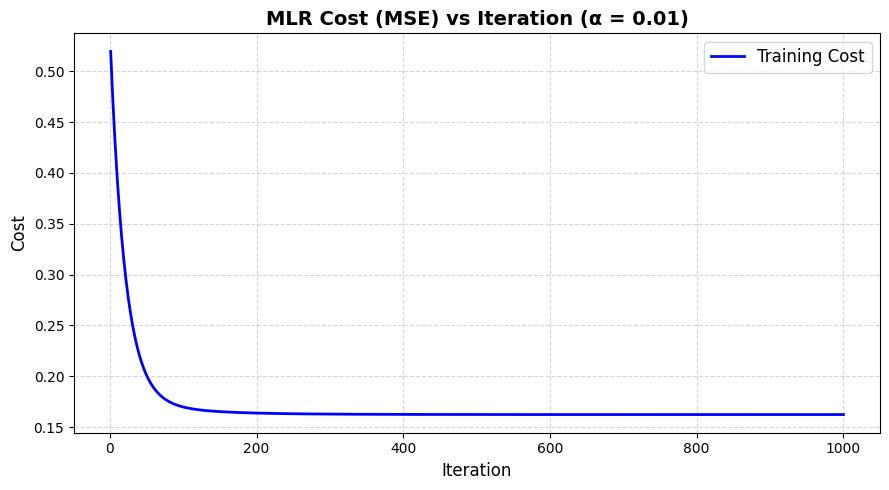


Cost is steadily decreasing — gradient descent is converging correctly.


In [49]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, iterations_mlr + 1), cost_history_mlr, color='blue', linewidth=2)
plt.title('MLR Cost (MSE) vs Iteration (α = 0.01)', fontsize=14, fontweight='bold')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(['Training Cost'], fontsize=12)
plt.tight_layout()
plt.show()

print("\nCost is steadily decreasing — gradient descent is converging correctly.")

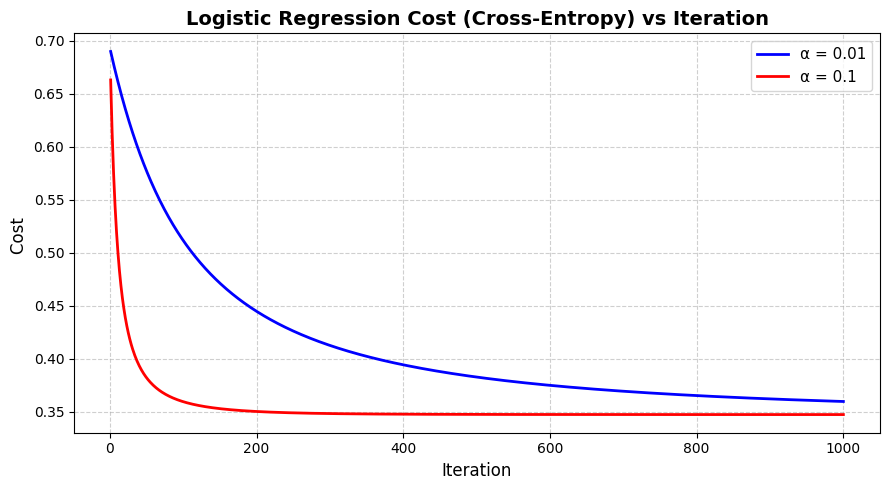


α=0.01 final cost: 0.359697
α=0.10 final cost: 0.347348

Conclusion: α=0.1 (red) converges faster and reaches a lower final cost within
1000 iterations.


In [55]:
plt.figure(figsize=(9, 5))
iters = range(1, 1001)
plt.plot(iters, cost_lr001, color='blue', linewidth=2, label='α = 0.01')
plt.plot(iters, cost_lr01,  color='red',    linewidth=2, label='α = 0.1')
plt.title('Logistic Regression Cost (Cross-Entropy) vs Iteration', fontsize=14, fontweight='bold')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost ', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"\nα=0.01 final cost: {cost_lr001[-1]:.6f}")
print(f"α=0.10 final cost: {cost_lr01[-1]:.6f}")
print()
print("Conclusion: α=0.1 (red) converges faster and reaches a lower final cost within")
print("1000 iterations.")

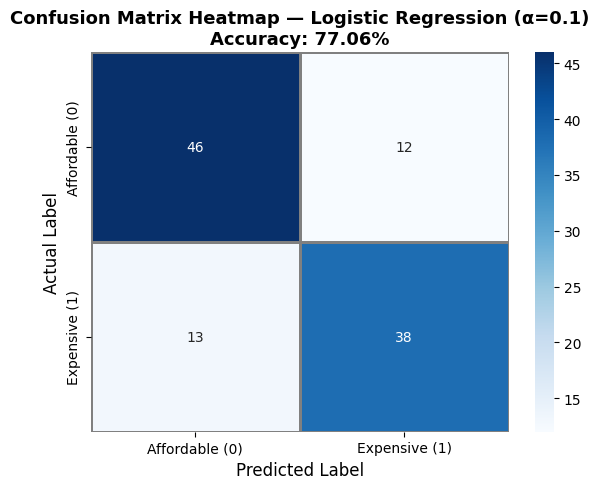

Heatmap Interpretation
True Negatives  (TN): 46  — affordable houses correctly predicted as affordable
True Positives  (TP): 38  — expensive houses correctly predicted as expensive
False Positives (FP): 12  — affordable houses wrongly classified as expensive
False Negatives (FN): 13  — expensive houses wrongly classified as affordable

Class 1 Precision: 0.760  |  Recall: 0.745

The model performs well overall. The heatmap shows the majority of predictions
fall on the main diagonal (TN and TP), indicating high accuracy. Any off-diagonal
cells represent misclassifications — a larger FP or FN count would indicate the
class the model finds harder to predict.


In [56]:
fig, ax = plt.subplots(figsize=(6, 5))

labels = ['Affordable (0)', 'Expensive (1)']
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=1,
    linecolor='gray',
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_title(f'Confusion Matrix Heatmap — Logistic Regression (α=0.1)\nAccuracy: {accuracy*100:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Heatmap Interpretation")
print(f"True Negatives  (TN): {TN}  — affordable houses correctly predicted as affordable")
print(f"True Positives  (TP): {TP}  — expensive houses correctly predicted as expensive")
print(f"False Positives (FP): {FP}  — affordable houses wrongly classified as expensive")
print(f"False Negatives (FN): {FN}  — expensive houses wrongly classified as affordable")
print()
precision_1 = TP / (TP + FP) if (TP + FP) > 0 else 0
recall_1    = TP / (TP + FN) if (TP + FN) > 0 else 0
print(f"Class 1 Precision: {precision_1:.3f}  |  Recall: {recall_1:.3f}")
print()
print("The model performs well overall. The heatmap shows the majority of predictions")
print("fall on the main diagonal (TN and TP), indicating high accuracy. Any off-diagonal")
print("cells represent misclassifications — a larger FP or FN count would indicate the")
print("class the model finds harder to predict.")